# 📊 Walmart Retail Sales Analysis and Forecasting

**Author:** Subhankar Mondal  
**Business Problem:** Walmart stores experience varying customer demand throughout the year, especially during holiday seasons. Accurate sales forecasting helps support inventory planning and improve operational decision-making.  
**Objective:** Analyze historical sales patterns, evaluate external factors, and build a SARIMAX forecasting model to predict future weekly sales and support inventory planning.  
**Tech Stack:** Python, Pandas, Numpy, Statsmodels (SARIMAX), Scikit-Learn (Metrics), Matplotlib, Seaborn.  

---

## 🎯 Project Architecture

* **Data Preparation:** Loaded, cleaned, and validated Walmart sales data.
* **Exploratory Data Analysis (EDA):** Analyzed sales trends, seasonality, and external factors such as unemployment and CPI using statistical analysis and visualizations.
* **Feature Engineering & Preprocessing:**  Applied a log transformation to stabilize sales variance and prepared the data for time series forecasting.
* **Forecasting Model:** Built a SARIMAX time series forecasting model and evaluated its performance using MAE, RMSE, and MAPE.
* **Business Insights:** Forecasted 12 weeks of future sales and translated results into inventory planning recommendations.


---
## Import Libraries

In [50]:
# Import 'os' for operating system interfaces and file path management
import os

# Import 'numpy' and 'pandas' for working with numbers and dataframes
import numpy as np
import pandas as pd

# Import 'pyplot' from 'matplotlib' and 'seaborn' for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Import Time Series Analysis Toolkit: trend, seasonality, stationarity, autocorrelation & partial autocorrelation plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller            
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Import SARIMAX model for time series forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Import evaluation metrics for model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set a professional visual theme for graphics
sns.set_theme(style='whitegrid')

# Import and execute method for suppressing warnings
import warnings
warnings.filterwarnings('ignore')


---
## Load the Dataset

In [51]:
DATA_PATH = "D:\Data Analytics Project\walmart-dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"File Missing: '{DATA_PATH}' not found in current directory."
        "Put your CSV file in the same folder as your notebook."
    )

print(f"Data verification successful: file located safely at '{DATA_PATH}'")

Data verification successful: file located safely at 'D:\Data Analytics Project\walmart-dataset.csv'


In [52]:
# Read dataset
df = pd.read_csv(DATA_PATH)

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,1,12-02-2010,"1,641,957.44",1,38.51,2.55,211.24,8.11
2,1,19-02-2010,"1,611,968.17",0,39.93,2.51,211.29,8.11
3,1,26-02-2010,"1,409,727.59",0,46.63,2.56,211.32,8.11
4,1,05-03-2010,"1,554,806.68",0,46.50,2.62,211.35,8.11


In [53]:
# Convert date into datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.sort_values('Date', inplace=True, ignore_index=True)

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11
1,10,2010-02-05,"2,193,048.75",0,54.34,2.96,126.44,9.77
2,37,2010-02-05,"536,006.73",0,45.97,2.57,209.85,8.55
3,17,2010-02-05,"789,036.02",0,23.11,2.67,126.44,6.55
4,30,2010-02-05,"465,108.52",0,39.05,2.57,210.75,8.32


In [54]:
# Check dataset shape, types and identify missing values
print(f"Dataset Shape (Rows, Columns): {df.shape}\n")

print("--- Data Types and Non-Null Counts ---\n")
df.info()

Dataset Shape (Rows, Columns): (6435, 8)

--- Data Types and Non-Null Counts ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [55]:
print("--- Statistical Summary ---")
df.describe()

--- Statistical Summary ---


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,"6,435.00",6435,"6,435.00","6,435.00","6,435.00","6,435.00","6,435.00","6,435.00"
mean,23.00,2011-06-17 00:00:00.000000256,"1,046,964.88",0.07,60.66,3.36,171.58,8.00
min,1.00,2010-02-05 00:00:00,"209,986.25",0.00,-2.06,2.47,126.06,3.88
25%,12.00,2010-10-08 00:00:00,"553,350.10",0.00,47.46,2.93,131.74,6.89
50%,23.00,2011-06-17 00:00:00,"960,746.04",0.00,62.67,3.44,182.62,7.87
75%,34.00,2012-02-24 00:00:00,"1,420,158.66",0.00,74.94,3.73,212.74,8.62
max,45.00,2012-10-26 00:00:00,"3,818,686.45",1.00,100.14,4.47,227.23,14.31
std,12.99,NaN,"564,366.62",0.26,18.44,0.46,39.36,1.88


In [56]:
# Check for missing values
print("--- Missing Values Discovered ---")
print(df.isnull().sum())


print(f"\nDuplicate Rows Discovered: {df.duplicated().sum()}")

--- Missing Values Discovered ---
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Duplicate Rows Discovered: 0


---
## Exploratory Data Analysis (EDA)

Explore sales trends, seasonality, and data distribution before building the forecasting model.

### Seasonal Trends

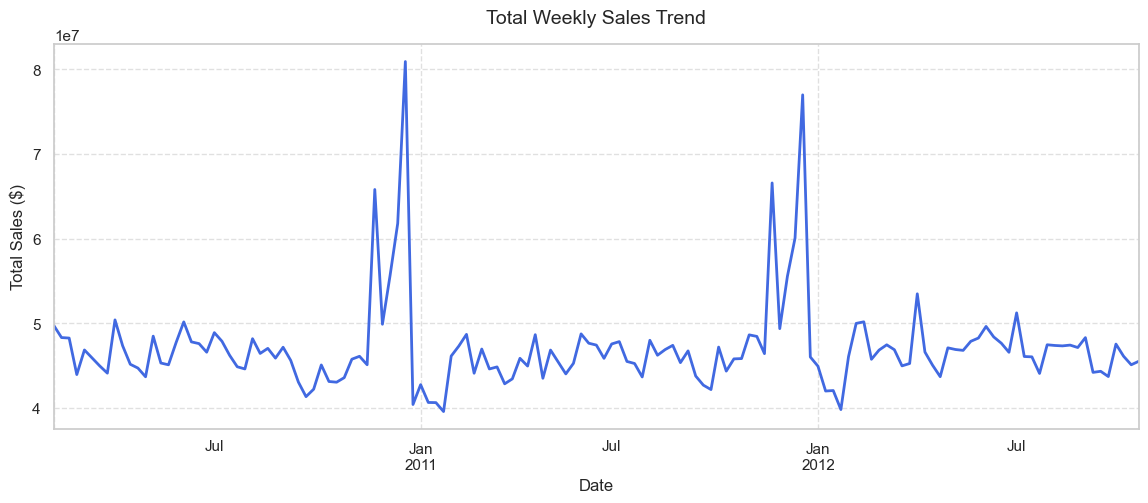

In [57]:
# Aggregate sales data by date across store
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()


plt.figure(figsize=(14, 5))
weekly_sales.plot(color='royalblue', linewidth=2)

plt.title("Total Weekly Sales Trend", fontsize=14, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

* **Growth Trend:** Outside of holiday periods, the baseline business remains highly stable and consistent
* **Seasonal Spikes & Holiday Peaks:** Significant sales spikes occur during the Q4 holiday season, especially around Thanksgiving and Christmas, highlighting the strong seasonal nature of retail demand.

### Correlation Matrix
In this section, we compute and visualize the linear relationships between all numerical variables in the dataset to discover hidden patterns.

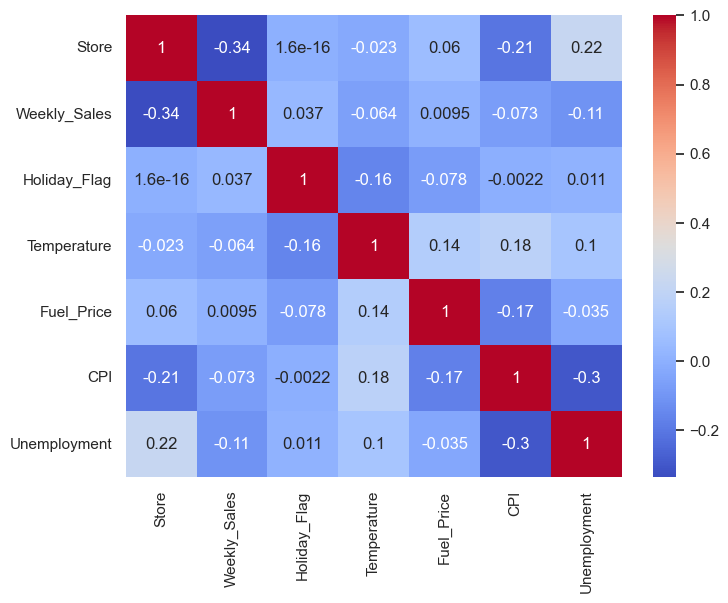

In [58]:
# Generate a correlation matrix heatmap
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

* **Unemployment Rate:** Shows a weak negative correlation (-0.11) with weekly sales, suggesting that higher unemployment is associated with slightly lower sales.

* **CPI (Consumer Price Index):** Shows a very weak negative correlation (-0.07) with weekly sales, indicating little linear relationship in this dataset.

* **Fuel Price:** Shows a near-zero correlation (0.01), indicating no meaningful linear relationship with weekly sales in this dataset.

* **Temperature:** Shows a weak negative correlation (-0.06) with weekly sales, indicating little overall relationship between temperature and sales.

* **Holiday Flag:** Shows a slight positive correlation (0.04) with weekly sales, suggesting that holiday weeks are generally associated with higher sales.

### Unemployment Rate Impact

In [59]:
# Calculate correlation per store between sales and unemployment
store_unemp_corrs = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['Unemployment'])).sort_values()

print("--- Top 5 Stores Suffering Most from Unemployment ---")
print(store_unemp_corrs.head(5))

--- Top 5 Stores Suffering Most from Unemployment ---
Store
38   -0.79
44   -0.78
39   -0.38
42   -0.36
41   -0.35
dtype: float64


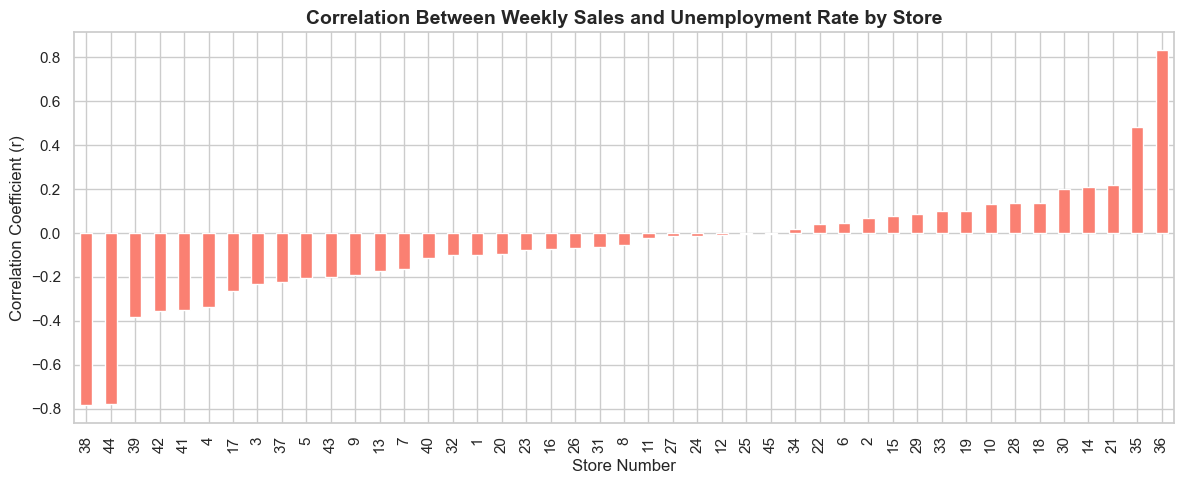

In [60]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 5))
store_unemp_corrs.plot(kind='bar', color='salmon', ax=ax)
ax.set_title('Correlation Between Weekly Sales and Unemployment Rate by Store', fontsize=14, fontweight='bold')
ax.set_xlabel('Store Number', fontsize=12)
ax.set_ylabel('Correlation Coefficient (r)', fontsize=12)
plt.tight_layout()
plt.show()

**Insight:** Store 38 (r = -0.7852) and Store 44 (r = -0.7801) show a strong negative correlation between unemployment and weekly sales, indicating that higher unemployment levels were associated with lower sales during the observed period.

### Temperature Impact

In [61]:
# Calculate temparature correlation per store
store_temp_corrs = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['Temperature'])).sort_values()
print("--- Top 5 Stores Affected Most by Temperature ---")
print(store_temp_corrs.head(5))

--- Top 5 Stores Affected Most by Temperature ---
Store
10   -0.43
12   -0.38
3    -0.38
28   -0.38
30   -0.33
dtype: float64


### Consumer Price Index (CPI) Impact

In [62]:
# Calculate CPI correlation per store
store_cpi_corrs = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['CPI'])).sort_values()
print("--- Top 5 Stores Affected Most by CPI ---")
print(store_cpi_corrs.head(5))

--- Top 5 Stores Affected Most by CPI ---
Store
36   -0.92
35   -0.42
14   -0.42
30   -0.30
43   -0.29
dtype: float64


---

### Store Performance Comparison Matrix

In [63]:
#Rank stores by total revenue and quantify performance variance metrics
store_sales = df.groupby('Store')['Weekly_Sales'].sum()
store_sales = store_sales.sort_values(ascending=False)

# Calculations for metrics
highest_store = store_sales.index[0]
lowest_store = store_sales.index[-1]
sales_diff = store_sales.max() - store_sales.min()
sales_ratio = store_sales.max() / store_sales.min()

print(f"Top Performer: Store {highest_store} (${store_sales.max():,.2f})")
print(f"Worst Performer: Store {lowest_store} (${store_sales.min():,.2f})")
print(f"Absolute Gap Difference: ${sales_diff:,.2f}")
print(f"Scale Performance Ratio: {sales_ratio:.2f}x")

Top Performer: Store 20 ($301,397,792.46)
Worst Performer: Store 33 ($37,160,221.96)
Absolute Gap Difference: $264,237,570.50
Scale Performance Ratio: 8.11x


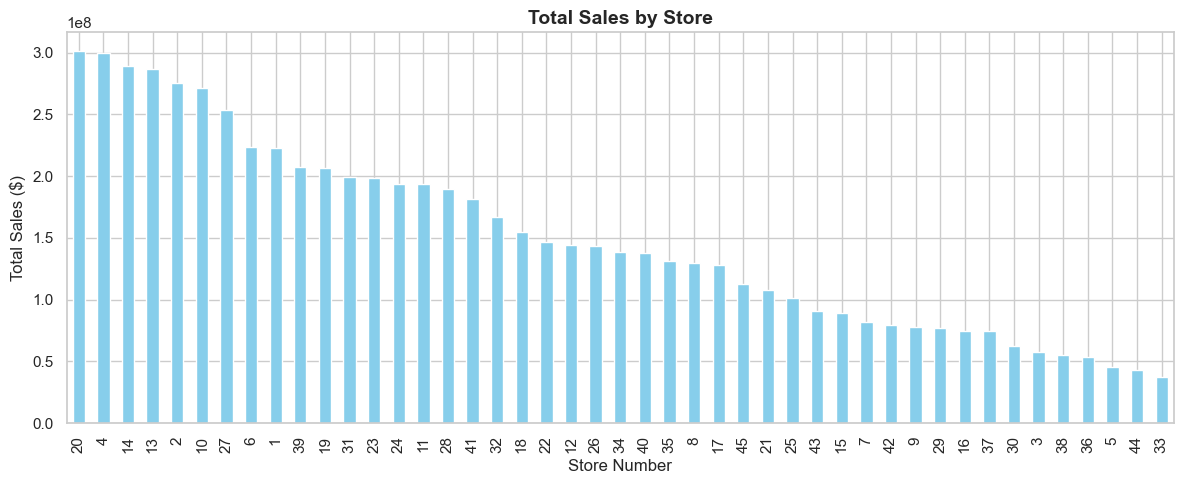

In [64]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 5))
store_sales.plot(kind='bar', color='skyblue', ax=ax)
ax.set_title('Total Sales by Store', fontsize=14, fontweight='bold')
ax.set_xlabel('Store Number', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
plt.tight_layout()

plt.show()

**Insight:** Store 20 is the top-performing store with cumulative historical revenue of $301,397,792.46. The worst-performing store is Store 33, generating only $37,160,221.96.

**Significance:** The absolute gap between them is a massive $264,237,570.50, meaning the highest-performing location earns 8.11× more revenue than the lowest-performing location.

---

## Pre-Modeling Diagnostics

The following analyses are performed before building the forecasting model:
- Seasonal decomposition
- ADF stationarity test
- ACF and PACF analysis

In [65]:
# Isolate to Store 1 for time-series forecasting
store1_df = df[df['Store'] == 1].copy()
store1_df = store1_df[['Date','Weekly_Sales']]
store1_df.set_index('Date', inplace=True)

store1_df.head()

,Weekly_Sales
Date,
2010-02-05,"1,643,690.90"
2010-02-12,"1,641,957.44"
2010-02-19,"1,611,968.17"
2010-02-26,"1,409,727.59"
2010-03-05,"1,554,806.68"


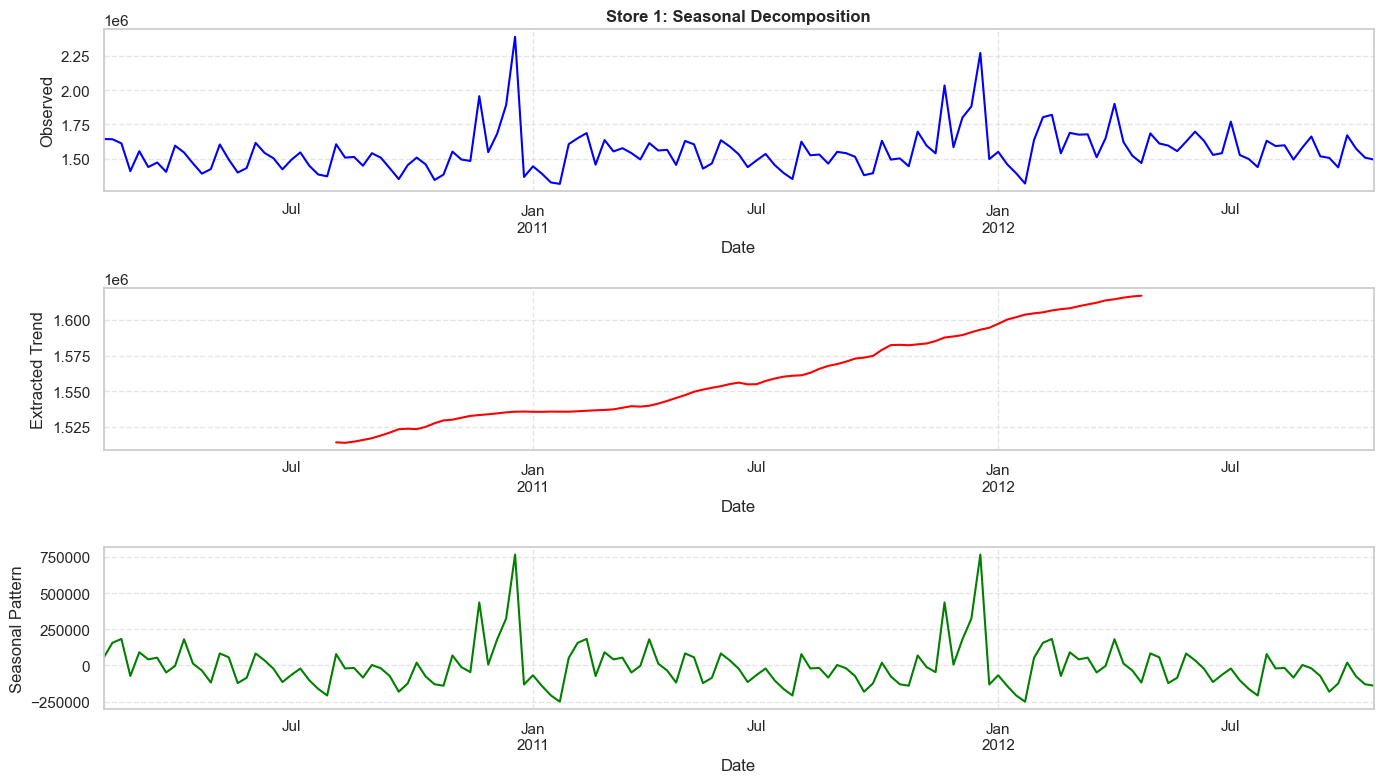

In [ ]:
# Visualizing Seasonal Decomposition
decomposition = seasonal_decompose(store1_df['Weekly_Sales'], model='additive', period=52)

# Plot the structural components on a 3-axis grid
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 8))

# Observed Log Data
decomposition.observed.plot(ax=ax1, color='blue')
ax1.set_title('Store 1: Seasonal Decomposition', fontsize=12, fontweight='bold')
ax1.set_ylabel('Observed')
ax1.grid(True, linestyle='--', alpha=0.5)

# Extracted Trend Component
decomposition.trend.plot(ax=ax2, color='red')
ax2.set_ylabel('Extracted Trend')
ax2.grid(True, linestyle='--', alpha=0.5)

# Seasonal Pattern Component
decomposition.seasonal.plot(ax=ax3, color='green')
ax3.set_ylabel('Seasonal Pattern')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

* **Trend & Seasonality:** The data shows a clear trend (a slow change in the overall level) and a repeating seasonal pattern (regular ups and downs). Because these patterns keep shifting over time, the data does not remain steady. This means the raw data is non‑stationary.

In [67]:
# Augmented Dickey-Fuller (ADF) Test
adf_test = adfuller(store1_df)
print(f"ADF Test Statistic: {adf_test[0]:.4f}")
print(f"ADF p-value: {adf_test[1]}")
if adf_test[1] < 0.05:
    print("Data is Stationary (p < 0.05).")
else:
    print("Data is Non-Stationary (p > 0.05).")

ADF Test Statistic: -5.1022
ADF p-value: 1.3877788330759535e-05
Data is Stationary (p < 0.05).


**Insight:** The ADF test was used as a statistical diagnostic before modeling. Since the series also showed increasing variance during holiday periods, a log transformation was applied to stabilize the data prior to model training.

---
## Train-Test Split
We will perform a chronological split, reserving the final 12 weeks of historical records to serve as our out-of-sample validation holdout.

In [68]:
train_data = store1_df.iloc[:-12]
test_data = store1_df.iloc[-12:]

In [69]:
# Display the training and testing periods
print(f"Training Period: {train_data.index.min():%Y-%m-%d} to {train_data.index.max():%Y-%m-%d} ({len(train_data)} weeks)")
print(f"Testing Period : {test_data.index.min():%Y-%m-%d} to {test_data.index.max():%Y-%m-%d} ({len(test_data)} weeks)")

Training Period: 2010-02-05 to 2012-08-03 (131 weeks)
Testing Period : 2012-08-10 to 2012-10-26 (12 weeks)


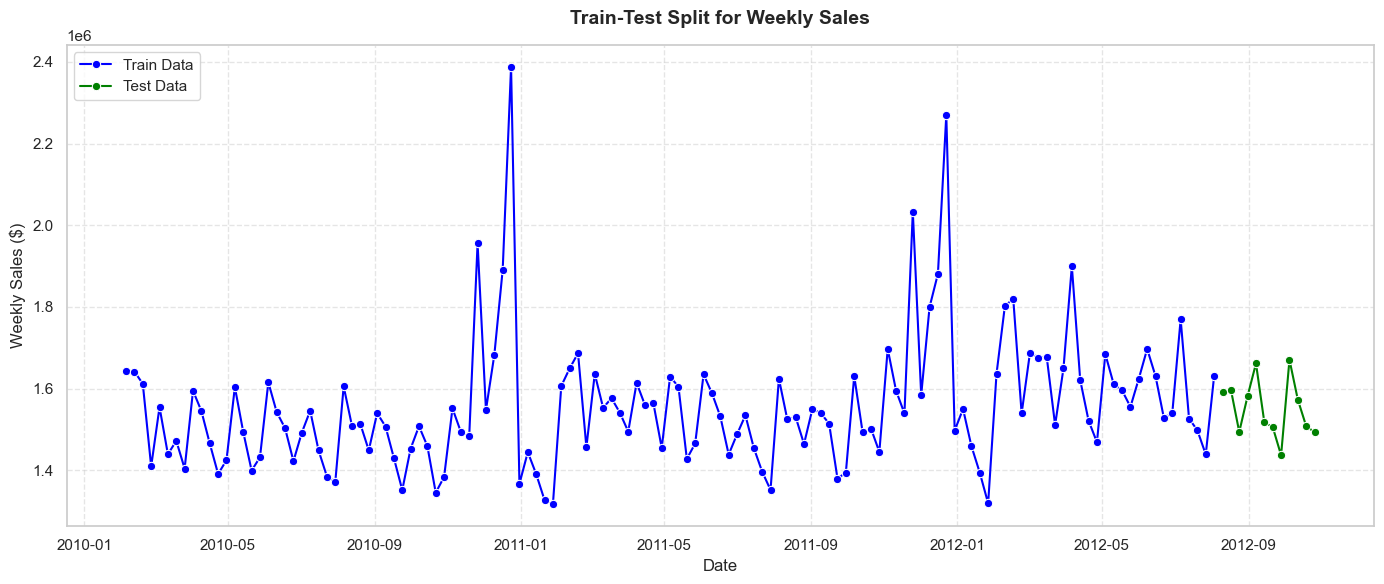

In [70]:
# Plot weekly sales data with the train-test split
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(data=train_data, x='Date', y='Weekly_Sales', marker='o', color='blue', label='Train Data', ax=ax)
sns.lineplot(data=test_data, x='Date', y='Weekly_Sales', marker='o', color='green', label='Test Data', ax=ax)

ax.set_title('Train-Test Split for Weekly Sales', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Weekly Sales ($)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

## Variance Stabilization
We will apply a natural log transformation (`np.log`) to stabilize the target variance.

In [71]:
train_data['Log_Weekly_Sales'] = np.log(train_data['Weekly_Sales'])

train_data.head()

,Weekly_Sales,Log_Weekly_Sales
Date,,
2010-02-05,"1,643,690.90",14.31
2010-02-12,"1,641,957.44",14.31
2010-02-19,"1,611,968.17",14.29
2010-02-26,"1,409,727.59",14.16
2010-03-05,"1,554,806.68",14.26


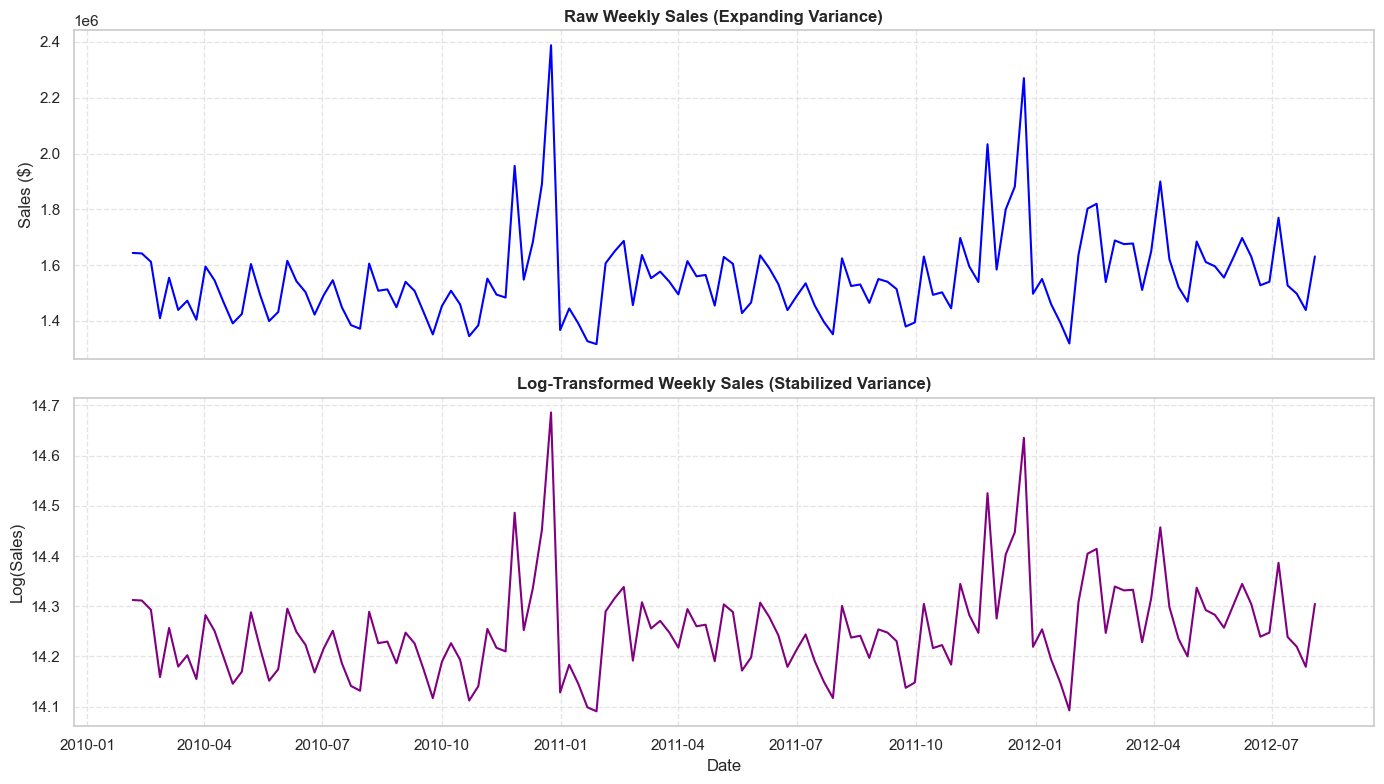

In [72]:
# Visual of variance stabilization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Raw Data
sns.lineplot(data=train_data, x='Date', y='Weekly_Sales', color='blue', ax=ax1)
ax1.set_title('Raw Weekly Sales (Expanding Variance)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sales ($)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Transformed Data
sns.lineplot(data=train_data, x='Date', y='Log_Weekly_Sales', color='purple', ax=ax2)
ax2.set_title('Log-Transformed Weekly Sales (Stabilized Variance)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Log(Sales)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## ACF and PACF Diagnostics
To identify the optimal parameters (p, d, q) for our time-series forecasting models, we evaluate the dataset's structure using Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) Plot

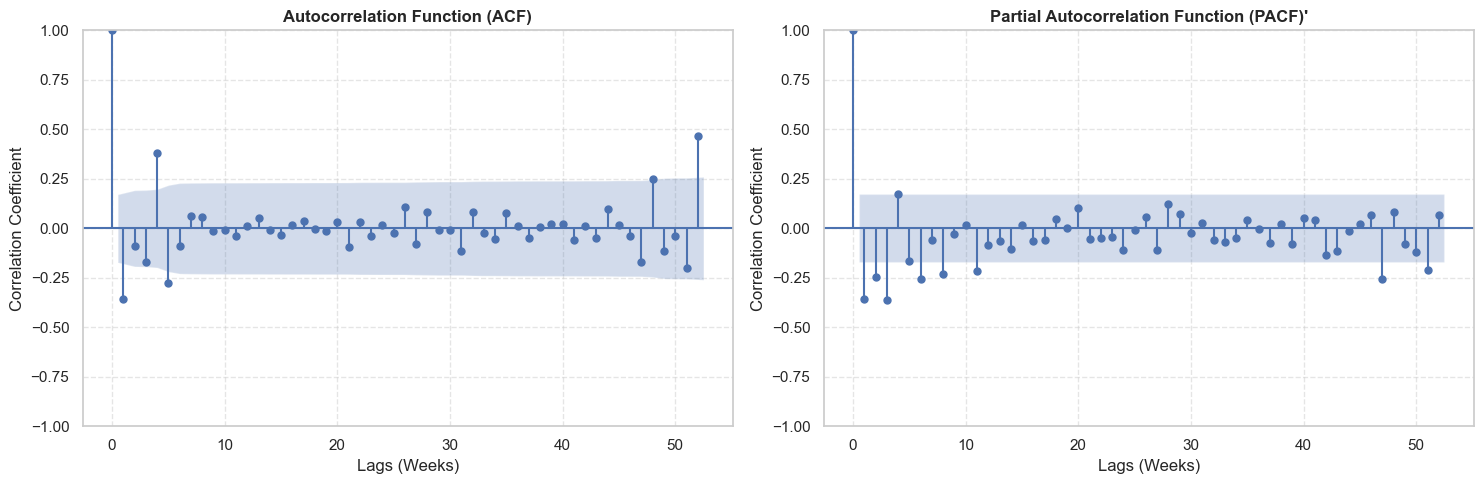

In [73]:
stationary_data = train_data['Log_Weekly_Sales'].diff().dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot the ACF on the first axis (to identify Moving Average 'q' term)
plot_acf(stationary_data, ax=ax1, lags=52)
ax1.set_title("Autocorrelation Function (ACF)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Lags (Weeks)")
ax1.set_ylabel("Correlation Coefficient")
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot the PACF on the second axis (to identify Autoregressive 'p' term)
plot_pacf(stationary_data, ax=ax2, lags=52)
ax2.set_title("Partial Autocorrelation Function (PACF)'", fontsize=12, fontweight='bold')
ax2.set_xlabel("Lags (Weeks)")
ax2.set_ylabel("Correlation Coefficient")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:** The ACF and PACF plots show a strong negative spike at Lag 1, indicating short-term autocorrelation after differencing. This provides an initial guide for selecting the AR (p) and MA (q) terms when configuring the SARIMAX model.

---
## Model Training and Evaluation

- **Model Training:** Train the SARIMAX model using the log-transformed training data.
- **Forecast Evaluation:** Convert the forecasts back to the original sales scale using `np.exp()` and evaluate performance using MAE, RMSE, and MAPE.

In [74]:
# Fit the SARIMA on the log training subset
sarima_model = SARIMAX(train_data['Log_Weekly_Sales'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 52),
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_model = sarima_model.fit()

In [75]:
# Generate forecasts for the test period (log scale)
train_len = len(train_data)
sarima_model_preds_log = sarima_model.predict(start = train_len, end = len(store1_df) - 1)


In [76]:
# Reverse the Log Transformation
sarima_model_preds =np.exp(sarima_model_preds_log)

In [77]:
# Convert data to NumPy arrays for evaluation
test_data_array = np.array(test_data)
sarima_model_preds_array = np.array(sarima_model_preds)

In [78]:
# Evaluate forecasting performance
mae = mean_absolute_error(test_data, sarima_model_preds)
rmse = np.sqrt(mean_squared_error(test_data, sarima_model_preds))
mape = np.mean(np.abs((test_data_array - sarima_model_preds_array) / test_data_array)) * 100

print(f"MAE : ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : $37,320.10
RMSE: $45,156.75
MAPE: 5.11%


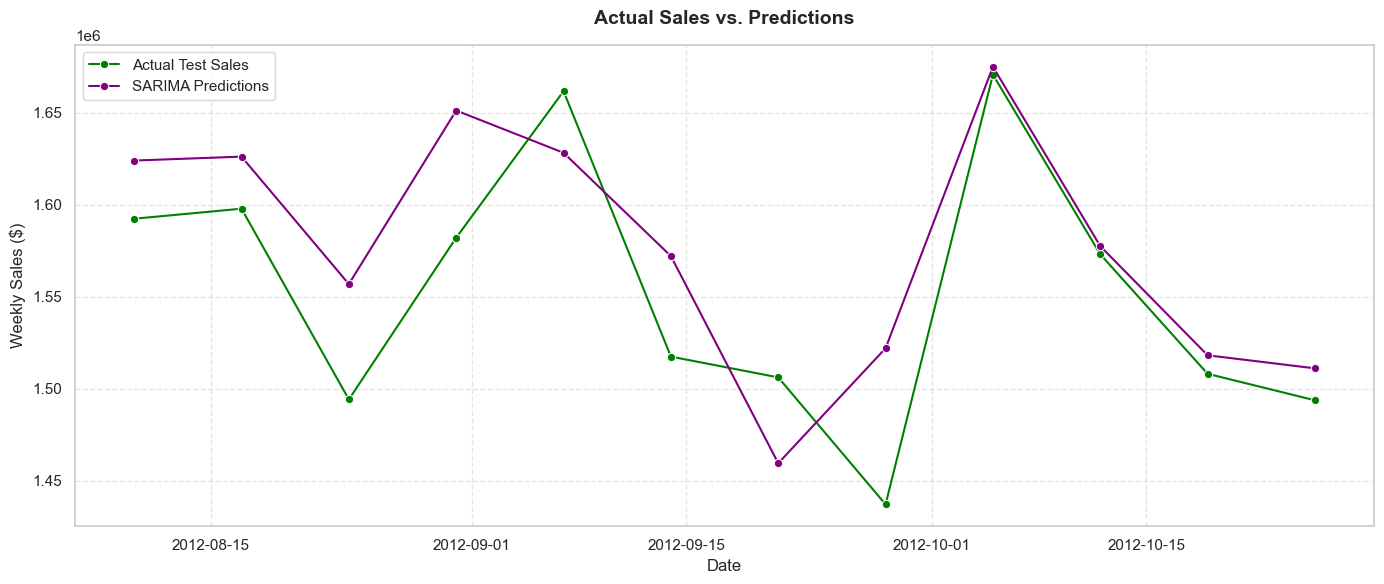

In [79]:
# Plot the time series data with the test-test split and predictions
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual test data
sns.lineplot(data=test_data, x='Date', y='Weekly_Sales', marker='o', color='green', label='Actual Test Sales', ax=ax)

# Plot model predictions
sns.lineplot(x=sarima_model_preds.index, y=sarima_model_preds.values, marker='o', color='purple', label='SARIMA Predictions', ax=ax)


ax.set_title('Actual Sales vs. Predictions', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Weekly Sales ($)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

---
## Future Forecast
Using the trained SARIMAX model, we forecast weekly sales for the next 12 weeks.

In [80]:
# Apply a log transformation to weekly sales
store1_df['Log_Weekly_Sales'] = np.log(store1_df['Weekly_Sales'])

store1_df.head()

,Weekly_Sales,Log_Weekly_Sales
Date,,
2010-02-05,"1,643,690.90",14.31
2010-02-12,"1,641,957.44",14.31
2010-02-19,"1,611,968.17",14.29
2010-02-26,"1,409,727.59",14.16
2010-03-05,"1,554,806.68",14.26


In [81]:
# Train the final SARIMAX model using the full historical dataset
final_model = SARIMAX(store1_df['Log_Weekly_Sales'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 52),
                                 enforce_stationarity=False, 
                                 enforce_invertibility=False)
final_model = final_model.fit()

In [82]:
# Project forecast for the next 12 future weeks
future_forecast_log = final_model.get_forecast(steps=12)

In [83]:
# Convert forecasts back to the original sales scale
future_forecast = np.exp(future_forecast_log.predicted_mean)
confidence_intervals = np.exp(future_forecast_log.conf_int())

In [84]:
# Create the 12-week sales forecast table
forecast_table = pd.DataFrame({
    'Projected_Demand_Sales': future_forecast,
    'Lower_Limit_95%': confidence_intervals.iloc[:, 0],
    'Upper_Limit_95%': confidence_intervals.iloc[:, 1]
})

pd.options.display.float_format = '{:,.2f}'.format
print(forecast_table)

            Projected_Demand_Sales  Lower_Limit_95%  Upper_Limit_95%
2012-11-02            1,725,918.29     1,602,066.16     1,859,345.16
2012-11-09            1,639,279.77     1,521,636.63     1,766,018.31
2012-11-16            1,602,384.68     1,487,214.30     1,726,473.88
2012-11-23            2,114,401.91     1,962,243.46     2,278,359.21
2012-11-30            1,659,022.68     1,539,485.59     1,787,841.51
2012-12-07            1,847,937.38     1,714,622.90     1,991,617.26
2012-12-14            1,995,187.59     1,851,071.59     2,150,523.80
2012-12-21            2,457,045.54     2,279,349.14     2,648,595.01
2012-12-28            1,521,450.18     1,411,281.36     1,640,219.11
2013-01-04            1,589,589.41     1,474,344.95     1,713,842.14
2013-01-11            1,511,600.57     1,401,875.73     1,629,913.58
2013-01-18            1,443,359.03     1,338,459.47     1,556,479.93


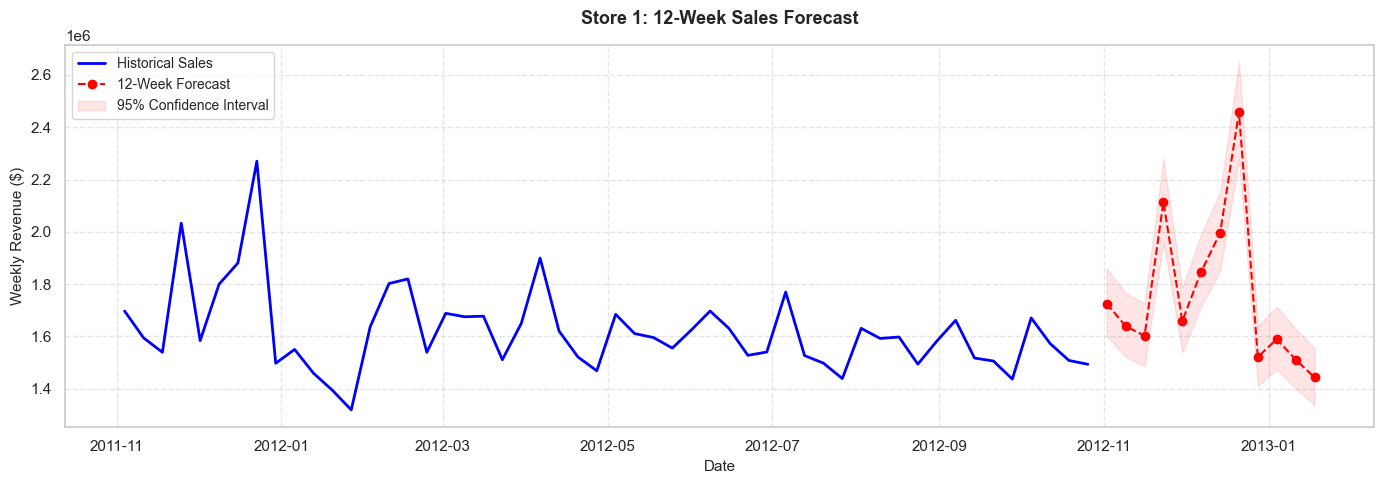

In [85]:
# Plot the final 12-week sales forecast
fig, ax = plt.subplots(figsize=(14, 5))

historical_slice = store1_df.tail(52)
ax.plot(historical_slice.index, historical_slice['Weekly_Sales'], label='Historical Sales', color='blue', linewidth=2)

ax.plot(future_forecast.index, future_forecast.values, label='12-Week Forecast', color='red', linestyle='--', marker='o')

ax.fill_between(confidence_intervals.index, 
                confidence_intervals.iloc[:, 0], 
                confidence_intervals.iloc[:, 1], 
                color='red', alpha=0.1, label='95% Confidence Interval')

ax.set_title('Store 1: 12-Week Sales Forecast', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Weekly Revenue ($)', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()